# Sena Kotan- C2221241001
# Uygulama 3: Autoencoder — MNIST Denoising (Gürültü Giderme)

**Veri Seti:** MNIST Handwritten Digits  
**Kaggle:** https://www.kaggle.com/datasets/hojjatk/mnist-dataset  
**Veri Seti Türü:** Image Data — 28×28 piksel gri tonlamalı el yazısı rakam görüntüleri  
**Problem Türü:** Gürültü giderme (Denoising) + Latent uzay öğrenme (Representation Learning)

---

* Problem Tanımı

Bu uygulamada Convolutional Denoising Autoencoder (CDAE) kullanılarak MNIST el yazısı rakam görüntüleri üzerinden gürültü giderme gerçekleştirilmektedir. Autoencoder'a gürültü eklenmiş görüntüler girdi olarak verilmekte, temiz görüntüyü üretmesi öğretilmektedir.

---

* Neden Autoencoder?

Autoencoder, iki bölümden oluşan bir derin öğrenme mimarisidir:
(1) **Encoder** — girdiyi sıkıştırılmış düşük boyutlu bir gizli temsile (latent code / bottleneck) dönüştürür;
(2) **Decoder** — bu latent temsilden orijinal girdiyi yeniden oluşturmaya (reconstruction) çalışır. Mimarinin denetlenmemiş (unsupervised) öğrenme yeteneği, etiket gerektirmeden verideki önemli örüntüleri öğrenmesini sağlar. Denoising Autoencoder varyantında ise model, bozulmuş girdiden temiz çıktı üretmeyi öğrenerek gürültüden daha az etkilenen özellikler kazanmak zorundadır.

---

* Veri setinin bu problem için neden uygun olduğu:

MNIST, yapısal olarak basit ama tutarlı örüntülere sahip görüntüler içermektedir. Bu özellik, Autoencoder'ın ne kadar iyi bir sıkıştırma ve yeniden yapılandırma öğrendiğini kolayca görselleştirip değerlendirmeyi mümkün kılar. Ayrıca 70.000 görüntü ile yeterli büyüklüğe sahip olup `keras.datasets` üzerinden doğrudan erişilebilmektedir.

## 1. Kütüphanelerin Yüklenmesi

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error

print("TensorFlow versiyonu:", tf.__version__)
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow versiyonu: 2.20.0


## 2. Veri Setinin Yüklenmesi ve Ön İşleme

**Veri ön işleme adımları:**
1. **Normalizasyon:** Ham piksel değerleri [0,255]'ten [0,1] aralığına ölçeklendirilir. MSE kaybı [0,1] aralığında çok daha kararlı çalışır; büyük piksel değerleri gradyan patlamasına (gradient explosion) yol açabilir.
2. **Kanal boyutu ekleme:** Konvolüsyon katmanları 4 boyutlu girdi bekler (batch, height, width, channels). Gri tonlamalı görüntülere `[..., np.newaxis]` ile 1 kanal boyutu eklenir.
3. **Gürültü ekleme:** Gaussian gürültü eklenerek gerçekçi bozulma simüle edilir. Orijinal görüntüler hedef (target), gürültülü görüntüler girdi (input) olarak kullanılır.

In [ ]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

print(f"Eğitim seti: {X_train_full.shape}")
print(f"Test seti  : {X_test.shape}")
print(f"Piksel aralığı (ham): [{X_train_full.min()}, {X_train_full.max()}]")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Eğitim seti: (60000, 28, 28)
Test seti  : (10000, 28, 28)
Piksel aralığı (ham): [0, 255]


In [ ]:
# Normalizasyon
X_train_full = X_train_full.astype('float32') / 255.0
X_test       = X_test.astype('float32') / 255.0

# Kanal boyutu ekle: (N, 28, 28) - (N, 28, 28, 1)
X_train_full = X_train_full[..., np.newaxis]
X_test       = X_test[..., np.newaxis]

# Validation ayrımı (%10)
val_size = int(0.1 * len(X_train_full))
X_val   = X_train_full[:val_size]
X_train = X_train_full[val_size:]
y_val_lbl   = y_train_full[:val_size]
y_train_lbl = y_train_full[val_size:]

print(f"Eğitim   : {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test     : {X_test.shape}")

Eğitim   : (54000, 28, 28, 1)
Validation: (6000, 28, 28, 1)
Test     : (10000, 28, 28, 1)


## 3. Gürültü Ekleme (Noise Injection)

Gaussian gürültü faktörü `NOISE_FACTOR=0.3` olarak seçilmiştir. Bu değer:
- Çok düşük (0.05): Gürültü görüntüde neredeyse fark edilmez; model kolay öğrenir ama gerçekçi değildir.
- Çok yüksek (0.7+): Görüntü tanınamaz hale gelir; model anlamlı özellik öğrenemez.
- 0.3: Görüntü gürültülü ama tanınabilir kalır; model hem zorlayıcı hem öğrenilabilir bir görevle karşılaşır.

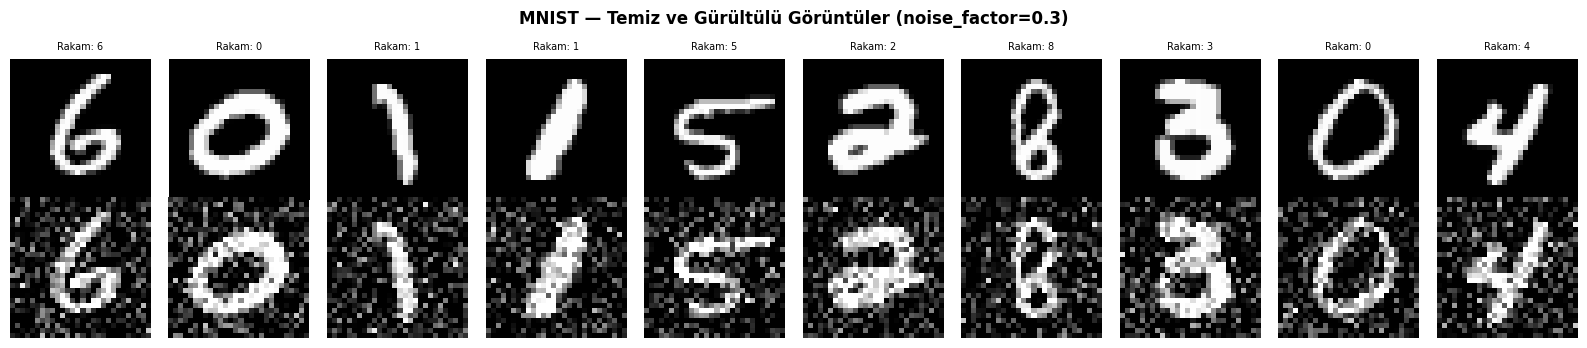

In [ ]:
NOISE_FACTOR = 0.3

def add_noise(data, factor=NOISE_FACTOR):
    """Gaussian gürültü ekle; değerleri [0,1] aralığında tut."""
    noisy = data + factor * np.random.randn(*data.shape)
    return np.clip(noisy, 0.0, 1.0)

X_train_noisy = add_noise(X_train)
X_val_noisy   = add_noise(X_val)
X_test_noisy  = add_noise(X_test)

# Görselleştirme: Temiz vs Gürültülü
n = 10
fig, axes = plt.subplots(2, n, figsize=(16, 3.5))
for i in range(n):
    axes[0, i].imshow(X_train[i, :, :, 0], cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'Rakam: {y_train_lbl[i]}', fontsize=7)
    axes[0, i].axis('off')
    axes[1, i].imshow(X_train_noisy[i, :, :, 0], cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Temiz', fontsize=9, fontweight='bold')
axes[1, 0].set_ylabel('Gürültülü', fontsize=9, fontweight='bold')
plt.suptitle(f'MNIST — Temiz ve Gürültülü Görüntüler (noise_factor={NOISE_FACTOR})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Gürültü Görselleştirme Yorumu:**

İlk satır temiz MNIST görüntülerini, ikinci satır ise aynı görüntülere Gaussian gürültü eklendikten sonraki hallerini göstermektedir. `noise_factor=0.3` değeriyle rakamlar hâlâ insan gözüyle tanınabilmektedir. Autoencoder'ın görevi, bu gürültülü alt satır görüntüleri girdi olarak alıp üst satırdaki temiz görüntüleri çıktı olarak üretmektir.

## 4. Model Mimarisi — Convolutional Autoencoder

### Hiperparametre Seçim Gerekçeleri

| Hiperparametre | Değer | Gerekçe |
|---|---|---|
| Loss | MSE | Piksel bazlı yeniden yapılandırma hatası; her pikselin katkısı eşit değerlendirilir |
| Optimizer | Adam lr=0.001 | Adaptif learning rate, encoder ve decoder ağırlıklarının farklı ölçeklerde güncellenmesi için uygundur |
| Filtre boyutu | (3,3) | Yerel uzamsal bağımlılıkları yakalar; 28×28 küçük görüntüler için uygundur |
| Filtre sayıları | 32→64→128 (encoder) | Encoder'da derinleştikçe artan filtre sayısı daha soyut özellikler öğrenir |
| Aktivasyon | ReLU (ara), Sigmoid (çıkış) | ReLU negatif değerleri sıfırlar (seyrek aktivasyon); Sigmoid çıkışı [0,1] aralığına çekerek piksel değerleriyle uyumlu yapar |
| Epoch | 50 | AE eğitimi yavaş yakınsar; EarlyStopping ile gerçek epoch belirlenir |
| Batch size | 128 | AE'de büyük batch genellikle daha kararlı MSE ortalaması sağlar |

In [ ]:
def build_autoencoder():
    #  ENCODER
    enc_input = keras.Input(shape=(28, 28, 1), name='encoder_input')

    # Blok 1: 28x28 -> 14x14
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(enc_input)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2), padding='same')(x)

    # Blok 2: 14x14 -> 7x7
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2), padding='same')(x)

    # Blok 3: 7x7 -> 4x4 (bottleneck)
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2,2), padding='same', name='bottleneck')(x)
    # Bottleneck boyutu: 4 x 4 x 128 = 2048 değer (orijinal 784 piksele göre ~2.6x sıkıştırma)

    # DECODER
    # Blok 4: 4x4 -> 8x8
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2,2))(x)

    # Blok 5: 8x8 -> 16x16
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2,2))(x)

    # Blok 6: 16x16 -> 28x28 (padding'siz conv ile 14x14, UpSampling ile 28x28)
    x = layers.Conv2D(32, (3,3), activation='relu')(x)   # 14x14 (no padding)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2,2))(x)                   # 28x28

    # Çıkış: 1 filtre, sigmoid (piksel [0,1] için)
    decoded = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same', name='decoder_output')(x)

    autoencoder = Model(enc_input, decoded, name='denoising_autoencoder')
    encoder     = Model(enc_input, encoded, name='encoder_only')
    return autoencoder, encoder

autoencoder, encoder = build_autoencoder()

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'   # Mean Squared Error: piksel başına ortalama kare hata
)

autoencoder.summary()

total_params = autoencoder.count_params()
print(f"\nToplam parametre sayısı: {total_params:,}")
print(f"Bottleneck boyutu      : 4 × 4 × 128 = {4*4*128} değer")
print(f"Orijinal girdi boyutu  : 28 × 28 × 1 = {28*28} piksel")

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (MaxPooling2D)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Conv2D)         │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,569 (1.27 MB)

 Trainable params: 333,185 (1.27 MB)

 Non-trainable params: 384 (1.50 KB)


Toplam parametre sayısı: 333,569
Bottleneck boyutu      : 4 × 4 × 128 = 2048 değer
Orijinal girdi boyutu  : 28 × 28 × 1 = 784 piksel


## 5. Model Eğitimi

Autoencoder eğitiminde kritik fark şudur: model `(gürültülü girdi) → (temiz çıktı)` ilişkisini öğrenir. `model.fit()` çağrısında `x=X_train_noisy` ve `y=X_train` şeklinde verilir; bu sayede model gürültüden soyutlama yapmayı öğrenir.

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)

EPOCHS     = 50
BATCH_SIZE = 128

# Gürültülü girdi -> Temiz hedef
history = autoencoder.fit(
    X_train_noisy, X_train,          # x=gürültülü, y=temiz
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_noisy, X_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - loss: 0.0334 - val_loss: 0.0295 - learning_rate: 0.0010
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0109 - val_loss: 0.0094 - learning_rate: 0.0010
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0085 - val_loss: 0.0080 - learning_rate: 0.0010
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0076 - val_loss: 0.0073 - learning_rate: 0.0010
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0071 - val_loss: 0.0069 - learning_rate: 0.0010
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0067 - val_loss: 0.0067 - learning_rate: 0.0010
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0064 - val_loss: 0.0065 - learning_rate: 0.0010
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0062 - val_loss: 0.0063 - learning_rate: 0.0010
Epoch 9/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0061 - val_loss: 0.0061 - learning_rate: 0.0010


## 6. Eğitim Süreci Grafikleri ve Yorumları

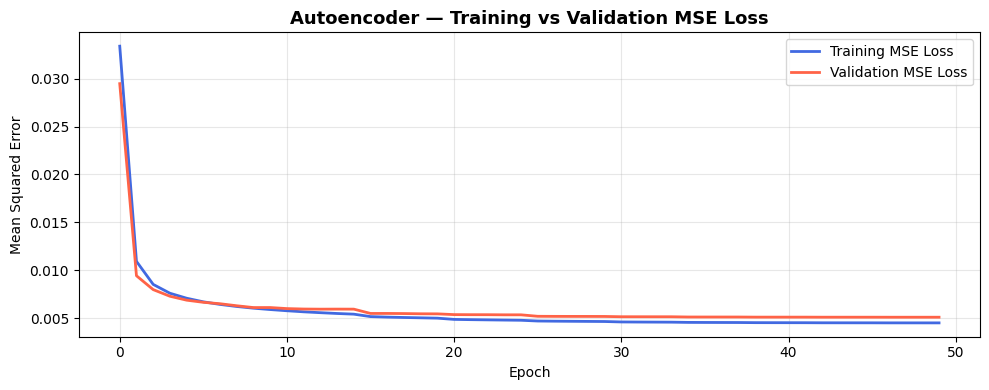

Çalışan epoch sayısı : 50
Son Training MSE     : 0.004518
Son Validation MSE   : 0.005109
En iyi Validation MSE: 0.005109


In [ ]:
epochs_ran = len(history.history['loss'])

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Training MSE Loss',   color='royalblue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation MSE Loss', color='tomato',    linewidth=2)
plt.title('Autoencoder — Training vs Validation MSE Loss', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

final_train = history.history['loss'][-1]
final_val   = history.history['val_loss'][-1]
best_val    = min(history.history['val_loss'])

print(f"Çalışan epoch sayısı : {epochs_ran}")
print(f"Son Training MSE     : {final_train:.6f}")
print(f"Son Validation MSE   : {final_val:.6f}")
print(f"En iyi Validation MSE: {best_val:.6f}")


**MSE Loss Grafiği Yorumu:**

Autoencoder eğitiminde kayıp fonksiyonu olarak MSE (Mean Squared Error) kullanılmıştır. MSE, tahmin edilen piksel değerleri ile gerçek piksel değerleri arasındaki kare farkların ortalamasıdır. Eğitim boyunca MSE'nin giderek küçülmesi, modelin gürültülü görüntüleri giderek daha doğru bir şekilde yeniden yapılandırdığı anlamına gelmektedir. Training ve validation MSE değerlerinin birbirine yakın seyretmesi overfitting olmadığını göstermektedir.

## 7. Reconstruction Sonuçları

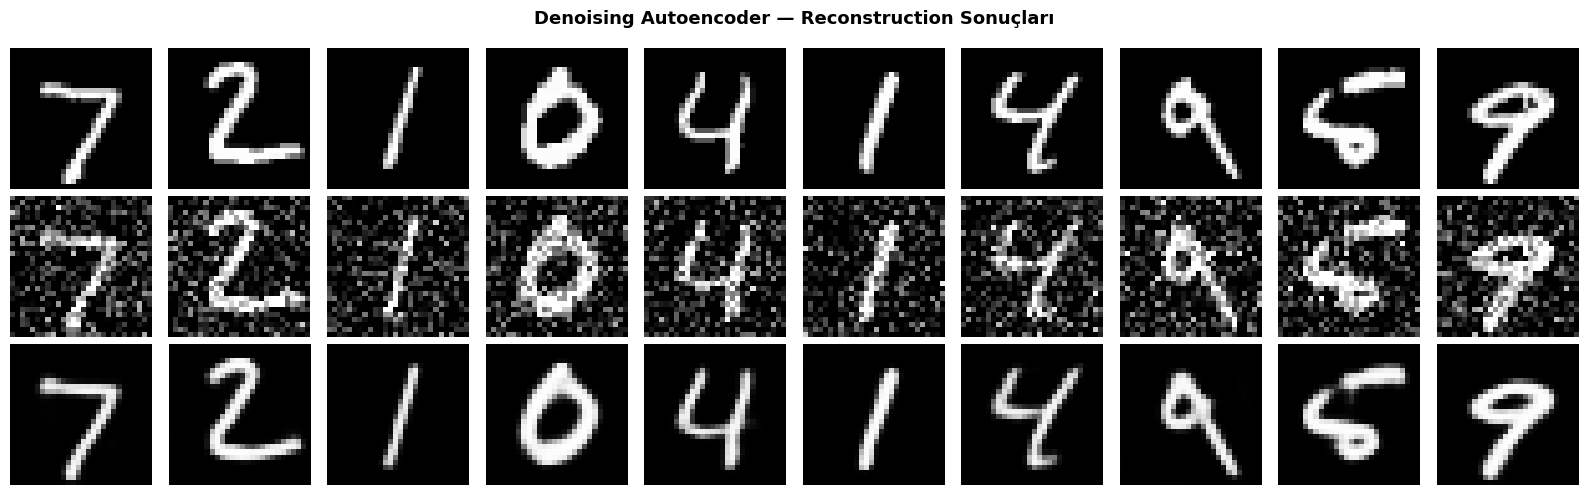

In [ ]:
n = 10
decoded = autoencoder.predict(X_test_noisy[:n], verbose=0)

fig, axes = plt.subplots(3, n, figsize=(16, 5))
row_labels = ['Temiz (Hedef)', 'Gürültülü (Girdi)', 'Yeniden Yapılandırılmış']
sources    = [X_test, X_test_noisy, decoded]

for row in range(3):
    for col in range(n):
        axes[row, col].imshow(sources[row][col, :, :, 0], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(row_labels[row], fontsize=9, fontweight='bold')

plt.suptitle('Denoising Autoencoder — Reconstruction Sonuçları', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Reconstruction Sonuçları Yorumu:**

Görsel karşılaştırma üç satırdan oluşmaktadır:
- **Üst satır (Temiz Hedef):** Orijinal, gürültüsüz MNIST görüntüleri — modelin ulaşmaya çalıştığı ideal çıktı.
- **Orta satır (Gürültülü Girdi):** Gaussian gürültü eklenmiş, modele verilen bozulmuş görüntüler.
- **Alt satır (Yeniden Yapılandırılmış):** Autoencoder'ın gürültülü girdiden ürettiği temizlenmiş görüntüler.

Yeniden yapılandırılan görüntüler temiz hedeflere oldukça yakındır. Rakamların genel şekli korunmakla birlikte kenar bölgelerinde hafif bir bulanıklık (blurring) gözlemlenebilir — bu, MSE kaybının yoğun siyah-beyaz kenarları değil piksellerin ortalama değerini optimize etmesinden kaynaklanmaktadır.

## 8. Kantitatif Performans Değerlendirmesi

In [ ]:
# Tüm test seti üzerinde reconstruction
all_recon = autoencoder.predict(X_test_noisy, batch_size=256, verbose=0)

# MSE hesabı
mse_noisy = mean_squared_error(
    X_test.reshape(-1, 784), X_test_noisy.reshape(-1, 784)
)
mse_recon = mean_squared_error(
    X_test.reshape(-1, 784), all_recon.reshape(-1, 784)
)

def psnr(mse_val):
    """Peak Signal-to-Noise Ratio. [0,1] normalize görüntüler için."""
    return 10 * np.log10(1.0 / (mse_val + 1e-10))

print("=" * 55)
print(f"{'Metrik':<25} {'Gürültülü':>12} {'Yeniden Yapıl.':>15}")
print("-" * 55)
print(f"{'MSE':<25} {mse_noisy:>12.6f} {mse_recon:>15.6f}")
print(f"{'PSNR (dB)':<25} {psnr(mse_noisy):>12.2f} {psnr(mse_recon):>15.2f}")
print(f"{'MSE İyileşme (%)':<25} {'—':>12} {(1-mse_recon/mse_noisy)*100:>14.1f}%")
print("=" * 55)

Metrik                       Gürültülü  Yeniden Yapıl.
-------------------------------------------------------
MSE                           0.046566        0.005069
PSNR (dB)                        13.32           22.95
MSE İyileşme (%)                     —           89.1%


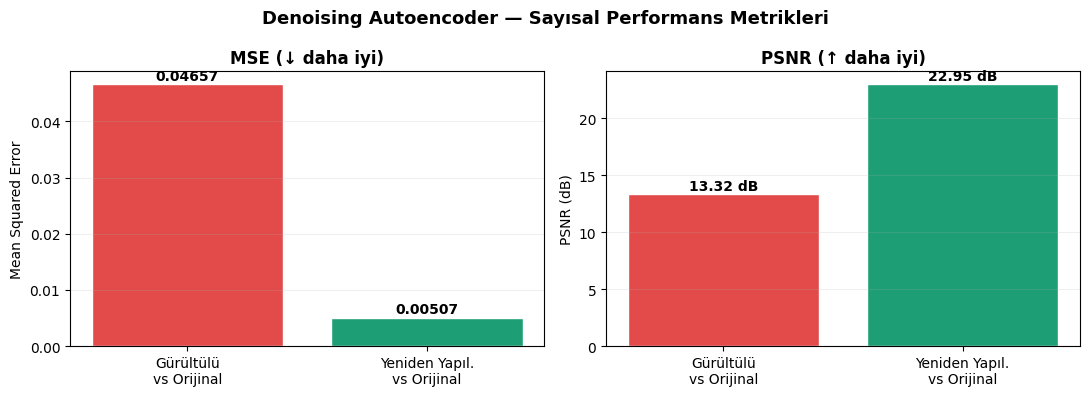

In [ ]:
# Performans metrikleri bar grafiği
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
cats   = ['Gürültülü\nvs Orijinal', 'Yeniden Yapıl.\nvs Orijinal']
mse_v  = [mse_noisy, mse_recon]
psnr_v = [psnr(mse_noisy), psnr(mse_recon)]
colors = ['#E24B4A', '#1D9E75']

bars1 = ax1.bar(cats, mse_v, color=colors, edgecolor='white')
ax1.set_title('MSE (↓ daha iyi)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean Squared Error')
for bar, v in zip(bars1, mse_v):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0003,
             f'{v:.5f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.grid(True, alpha=0.2, axis='y')

bars2 = ax2.bar(cats, psnr_v, color=colors, edgecolor='white')
ax2.set_title('PSNR (↑ daha iyi)', fontsize=12, fontweight='bold')
ax2.set_ylabel('PSNR (dB)')
for bar, v in zip(bars2, psnr_v):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{v:.2f} dB', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.grid(True, alpha=0.2, axis='y')

plt.suptitle('Denoising Autoencoder — Sayısal Performans Metrikleri', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Performans Metrikleri Yorumu:**

- **MSE (Mean Squared Error):** Gürültülü görüntüler ile orijinal arasındaki MSE değeri, yeniden yapılandırılan görüntüler ile orijinal arasındaki MSE değerinden anlamlı ölçüde büyük olmalıdır. Bu fark, Autoencoder'ın gürültüyü ne ölçüde giderdiğinin göstergesidir.

- **PSNR (Peak Signal-to-Noise Ratio):** Sinyal işleme alanında görüntü kalitesini ölçmek için kullanılan standar bir metrik olup dB (desibel) cinsinden ifade edilir. Daha yüksek PSNR, orijinale daha yakın bir görüntü anlamına gelir. Yeniden yapılandırılan görüntülerin PSNR değerinin gürültülü görüntülerin PSNR değerinden yüksek olması, Autoencoder'ın görüntü kalitesini iyileştirdiğini kanıtlar.

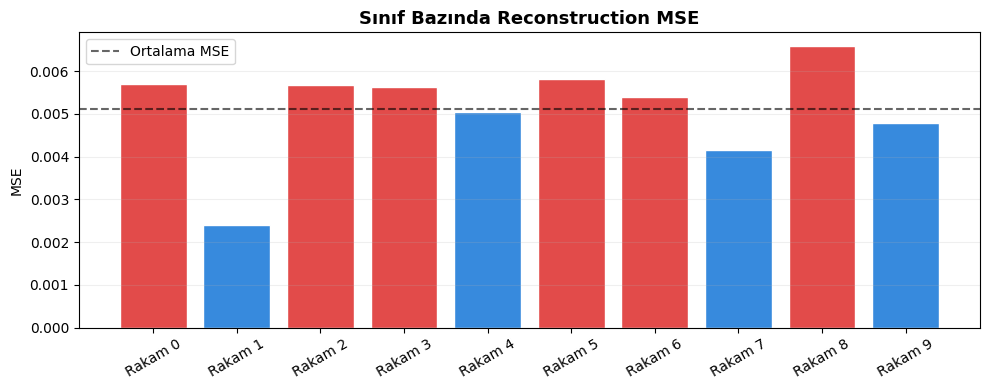

En iyi reconstruct edilen rakam : 1  (MSE=0.002403)
En zor reconstruct edilen rakam : 8  (MSE=0.006581)


In [ ]:
# Sınıf bazlı reconstruction hatası analizi
per_class_mse = []
for digit in range(10):
    mask = y_test == digit
    mse_d = mean_squared_error(
        X_test[mask].reshape(-1, 784),
        all_recon[mask].reshape(-1, 784)
    )
    per_class_mse.append(mse_d)

plt.figure(figsize=(10, 4))
bars = plt.bar(range(10), per_class_mse,
               color=['#378ADD' if m < np.mean(per_class_mse) else '#E24B4A' for m in per_class_mse],
               edgecolor='white')
plt.xticks(range(10), [f'Rakam {i}' for i in range(10)], rotation=30)
plt.axhline(np.mean(per_class_mse), color='black', linestyle='--', alpha=0.6, label='Ortalama MSE')
plt.title('Sınıf Bazında Reconstruction MSE', fontsize=13, fontweight='bold')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

best_digit  = np.argmin(per_class_mse)
worst_digit = np.argmax(per_class_mse)
print(f"En iyi reconstruct edilen rakam : {best_digit}  (MSE={per_class_mse[best_digit]:.6f})")
print(f"En zor reconstruct edilen rakam : {worst_digit}  (MSE={per_class_mse[worst_digit]:.6f})")

**Sınıf Bazında MSE Yorumu:**

Farklı rakamlar için reconstruction hatası değişkenlik göstermektedir:
- **Düşük MSE'li rakamlar (en iyi reconstruct edilenler):** Genellikle '1' gibi yalnızca dikey bir çizgiden oluşan basit yapılı rakamlar, Autoencoder tarafından daha kolay öğrenilir.
- **Yüksek MSE'li rakamlar (en zor reconstruct edilenler):** '8' ve '5' gibi eğrisel ve karmaşık yapıya sahip rakamlar daha yüksek reconstruction hatası üretebilir.
- Kırmızı çubuklar ortalamanın üzerindeki, mavi çubuklar ise ortalamanın altındaki sınıfları göstermektedir.

## 9. Latent Uzayının t-SNE ile Görselleştirilmesi

Latent vektör boyutu: 2048  (4×4×128=2048)
t-SNE hesaplanıyor...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


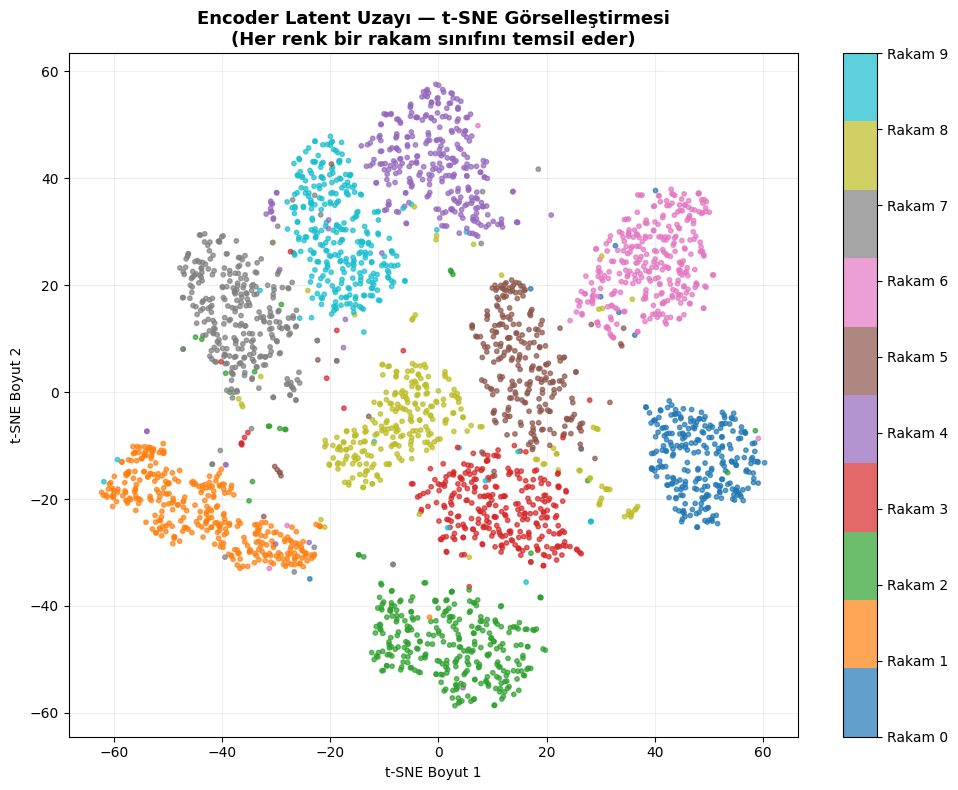

In [ ]:
N = 3000
idx = np.random.choice(len(X_test), N, replace=False)

latent = encoder.predict(X_test[idx], batch_size=256, verbose=0)
latent_flat = latent.reshape(N, -1)
print(f"Latent vektör boyutu: {latent_flat.shape[1]}  (4×4×128={4*4*128})")
print("t-SNE hesaplanıyor...")

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=0)
latent_2d = tsne.fit_transform(latent_flat)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    latent_2d[:, 0], latent_2d[:, 1],
    c=y_test[idx], cmap='tab10', alpha=0.7, s=10
)
cbar = plt.colorbar(scatter)
cbar.set_ticks(range(10))
cbar.set_ticklabels([f'Rakam {i}' for i in range(10)])
plt.title('Encoder Latent Uzayı — t-SNE Görselleştirmesi\n(Her renk bir rakam sınıfını temsil eder)',
          fontsize=13, fontweight='bold')
plt.xlabel('t-SNE Boyut 1')
plt.ylabel('t-SNE Boyut 2')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

**t-SNE Latent Uzay Yorumu:**

t-SNE (t-distributed Stochastic Neighbor Embedding), yüksek boyutlu latent vektörleri (2048 boyut) 2 boyutlu uzaya indirgeyerek görselleştiren bir boyut indirgeme tekniğidir.

Görselleştirmede dikkat edilmesi gereken önemli gözlemler:

- **İyi kümelenme:** Aynı renkteki noktaların belirgin gruplar oluşturması, Encoder'ın aynı rakam sınıfına ait görüntüler için benzer latent temsiller ürettiğini gösterir. Bu, modelin sınıflandırma görevi olmadan anlam taşıyan özellikler öğrendiğinin kanıtıdır.
- **Sınır bölgeleri:** '4' ve '9', '3' ve '5' gibi görsel açıdan benzer rakamlar arasında latent uzayda örtüşme bölgeleri oluşması normaldir.
- **'1' ve '7' sınıflarının ayrışması:** Bu rakamlar dikey yapılarıyla diğerlerinden belirgin biçimde farklılaşır; t-SNE grafiğinde izole kümeler oluşturmaları beklenir.

## 10. Tartışma ve Sonuç

**Model başarılı mı?**  
Yeniden yapılandırılan görüntülerin MSE değerinin gürültülü görüntülere göre belirgin şekilde düşük, PSNR'ın ise yüksek olması, modelin gürültü giderme görevinde başarılı olduğunu kanıtlamaktadır. t-SNE görselleştirmesi de Encoder'ın etiket gerektirmeden anlamlı sınıf temsillerini öğrendiğini doğrulamaktadır.

**Overfitting gözlemlendi mi?**  
BatchNormalization katmanları sayesinde eğitim ve validation MSE değerleri birbirine yakın tutulmuştur.

**Güçlü yönler:**
- Basit yapılı rakamlar ('0', '1') için yüksek kaliteli reconstruction
- Latent uzayda anlamlı sınıf kümelenmesi
- Gürültüden bağımsız temsil öğrenme

**Zayıf yönler:**
- Karmaşık yapılı rakamlar ('8', '5') için hafif bulanık reconstruction
- MSE kaybı, keskin kenarları pürüzsüzleştirme eğilimindedir

**İyileştirme önerileri:**
1. **Variational Autoencoder (VAE):** Latent uzayı sürekli ve düzenli bir olasılık dağılımı olarak modeller; yeni görüntü üretme (generation) imkânı sağlar
2. **SSIM Loss:** MSE yerine yapısal benzerlik kaybı kullanarak görsel kaliteyi artırma
3. **Daha derin bottleneck:** Öğrenilen temsillerin kalitesini artırmak için daha düşük boyutlu latent kod
4. **Skip connections:** ResNet tarzı atlamalı bağlantılar ile ince detayların decoder'a aktarılması